# 08. One-Class Classification and Support Vector Methods

The previous notebook used Isolation Forest to isolate unusual cases with random tree partitions. This notebook studies a different idea: **learn the boundary of acceptable behavior from normal examples only**.

One-class classification is useful when the organization has many examples of normal operation but few reliable examples of failures, fraud, intrusions, or abuse. Instead of learning a normal-versus-anomaly classifier, the model estimates a region that contains most normal cases. Future points outside that region are treated as review candidates.

We focus on support-vector methods:

1. **Support Vector Data Description (SVDD):** fit a compact boundary around target data.
2. **One-Class SVM:** separate normal data from the origin in a kernel feature space.
3. **Operational calibration:** convert boundary scores into review queues, thresholds, and monitoring rules.

The decision-science theme is that one-class methods encode assumptions as well as algorithms. They are assumptions about what counts as normal support, how much normal variation to tolerate, and how much review capacity to spend on boundary violations.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain one-class classification as support estimation rather than binary classification.
2. Describe the SVDD and One-Class SVM objectives at a conceptual and mathematical level.
3. Interpret the roles of `nu`, kernel choice, and RBF bandwidth.
4. Train a One-Class SVM using normal-only baseline data.
5. Distinguish model boundary violations from a fixed operational review budget.
6. Compare linear and RBF one-class boundaries.
7. Diagnose sensitivity to `nu` and `gamma`.
8. Explain selected alerts using nearest-normal-neighbor context and feature replacement diagnostics.

In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebooks' / '_shared' / 'display.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_SEED = 17

PALETTE = {
    'normal_office': '#9aaec1',
    'normal_remote': '#6fb7a8',
    'impossible_travel': '#d95f5f',
    'credential_stuffing': '#f28e2b',
    'new_device_takeover': '#8b6fd6',
    'stealthy_misuse': '#c27ba0',
    'alert': '#7b61ff',
    'boundary': '#1f6f64',
    'decision': '#1f6f64',
}

## 1. One-Class Classification

In ordinary supervised classification, we observe examples from multiple classes. In one-class classification, we usually observe only the target class. The target class is the set of cases we are willing to treat as normal, healthy, permitted, or acceptable.

Let $x_1,\ldots,x_n$ be normal training examples drawn from an unknown distribution $P$. The goal is to estimate a set $S$ such that

$$
P(X \in S) \ge 1 - \alpha.
$$

A future point outside $S$ is outside the learned support of normal behavior and should be reviewed before labeling it malicious or defective.

This distinction matters in industry settings. One-class models are well suited to novelty detection when normal examples are plentiful but anomaly labels are incomplete, delayed, adversarial, or not yet observed.

## 2. SVDD and One-Class SVM

Support Vector Data Description fits a compact boundary around target data (Tax & Duin, 2004). In its simplest form, SVDD seeks a center $a$ and radius $R$ so most target points lie inside a sphere:

$$
\min_{a,R,\xi} R^2 + C\sum_{i=1}^{n}\xi_i
$$

subject to

$$
\lVert \phi(x_i) - a \rVert^2 \le R^2 + \xi_i,
$$

where $\phi(\cdot)$ is a feature map and $\xi_i$ are slack variables.

One-Class SVM takes a related support-estimation view (Schölkopf et al., 2001). It finds a hyperplane in feature space that separates mapped data from the origin:

$$
\min_{w,\rho,\xi} \frac{1}{2}\lVert w \rVert^2 + \frac{1}{\nu n}\sum_{i=1}^{n}\xi_i - \rho
$$

subject to

$$
w^\top \phi(x_i) \ge \rho - \xi_i, \qquad \xi_i \ge 0.
$$

The decision function is

$$
f(x) = w^\top \phi(x) - \rho.
$$

A point is inside the learned normal region when $f(x) \ge 0$ and outside when $f(x) < 0$.

## 3. The Role of `nu`, Kernels, and Bandwidth

The parameter `nu` is central. It is often described as controlling the tolerated fraction of training points that can fall outside the boundary and the fraction of support vectors. In practice, larger `nu` usually means a tighter boundary and more training rejections. We still inspect the realized training rejection rate, because kernel choice and feature geometry can make the nominal `nu` story misleading for a particular deployment.

The kernel controls the shape of the boundary.

| Choice | Meaning | Operational risk |
|---|---|---|
| Linear kernel | One broad half-space in feature space | Too rigid for multi-regime normal behavior |
| RBF kernel with small `gamma` | Smooth, broad boundary | May miss local abnormality |
| RBF kernel with large `gamma` | Flexible, tight boundary | May overfit normal noise and over-alert |

This notebook will repeatedly separate two ideas:

| Quantity | Meaning |
|---|---|
| Model boundary | The learned inside/outside rule from One-Class SVM |
| Review threshold | The operating rule used to fill a human review queue |

The model boundary is useful, but the review threshold often needs to reflect staffing, escalation cost, and business risk.

## 4. Synthetic Case: Login Risk Monitoring

Imagine an identity platform that monitors login sessions. The security team has a large baseline of sessions believed to be legitimate. The platform must review future sessions that look outside normal behavior.

Normal sessions include two acceptable regimes:

| Regime | Description |
|---|---|
| `normal_office` | Routine office-hour logins from familiar devices and networks |
| `normal_remote` | Legitimate remote-work logins with somewhat higher risk scores and more MFA prompts |

Future risky sessions include impossible travel, credential-stuffing behavior, new-device takeover, and stealthier misuse patterns.

The decision question asks **can a normal-only support boundary identify risky login sessions while preserving legitimate remote work?**

In [2]:
# Section focus: 4. Synthetic Case: Login Risk Monitoring.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def simulate_login_monitoring(n_train_normal=2200, n_future_office=1700, n_future_remote=750, n_anomaly=220, seed=RANDOM_SEED):
    """Create a simulated login monitoring data set for the 08. One-Class Classification and Support Vector Methods case study.
    
    Parameters
    ----------
    n_train_normal : object
        Count or size setting for the login monitoring calculation.
    n_future_office : object
        Count or size setting for the login monitoring calculation.
    n_future_remote : object
        Count or size setting for the login monitoring calculation.
    n_anomaly : object
        Count or size setting for the login monitoring calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rng = np.random.default_rng(seed)
    feature_cols = [
        'hour_sin',
        'hour_cos',
        'geo_velocity_kmh',
        'failed_attempts',
        'device_risk_score',
        'ip_reputation_score',
        'mfa_prompts',
        'session_duration_min',
        'account_age_days',
    ]

    def normal_office(n):
        """Carry out the normal office step used in the 08. One-Class Classification and Support Vector Methods workflow.
        
        Parameters
        ----------
        n : object
            Number of observations or simulation units used by the calculation.
        
        Returns
        -------
        object
            pandas.DataFrame containing the tabular result produced by this function.
        """
        hour = np.mod(rng.normal(13, 3, n), 24)
        return pd.DataFrame({
            'hour_sin': np.sin(2 * np.pi * hour / 24),
            'hour_cos': np.cos(2 * np.pi * hour / 24),
            'geo_velocity_kmh': np.clip(rng.gamma(1.6, 18, n), 0, 220),
            'failed_attempts': rng.poisson(0.12, n),
            'device_risk_score': np.clip(rng.normal(18, 8, n), 0, 100),
            'ip_reputation_score': np.clip(rng.normal(14, 7, n), 0, 100),
            'mfa_prompts': rng.poisson(0.18, n),
            'session_duration_min': np.clip(rng.lognormal(np.log(28), 0.45, n), 2, 240),
            'account_age_days': np.clip(rng.gamma(5, 140, n), 10, 3000),
            'regime': 'normal_office',
        })

    def normal_remote(n):
        """Carry out the normal remote step used in the 08. One-Class Classification and Support Vector Methods workflow.
        
        Parameters
        ----------
        n : object
            Number of observations or simulation units used by the calculation.
        
        Returns
        -------
        object
            pandas.DataFrame containing the tabular result produced by this function.
        """
        hour = np.mod(rng.normal(19, 4, n), 24)
        return pd.DataFrame({
            'hour_sin': np.sin(2 * np.pi * hour / 24),
            'hour_cos': np.cos(2 * np.pi * hour / 24),
            'geo_velocity_kmh': np.clip(rng.gamma(2.0, 35, n), 0, 380),
            'failed_attempts': rng.poisson(0.22, n),
            'device_risk_score': np.clip(rng.normal(31, 11, n), 0, 100),
            'ip_reputation_score': np.clip(rng.normal(24, 10, n), 0, 100),
            'mfa_prompts': rng.poisson(0.45, n),
            'session_duration_min': np.clip(rng.lognormal(np.log(35), 0.50, n), 2, 260),
            'account_age_days': np.clip(rng.gamma(4.5, 120, n), 10, 2600),
            'regime': 'normal_remote',
        })

    n1 = int(0.34 * n_anomaly)
    n2 = int(0.30 * n_anomaly)
    n3 = int(0.22 * n_anomaly)
    n4 = n_anomaly - n1 - n2 - n3

    hour = np.mod(rng.normal(3, 2, n1), 24)
    impossible_travel = pd.DataFrame({
        'hour_sin': np.sin(2 * np.pi * hour / 24),
        'hour_cos': np.cos(2 * np.pi * hour / 24),
        'geo_velocity_kmh': np.clip(rng.normal(920, 170, n1), 250, 1600),
        'failed_attempts': rng.poisson(0.7, n1),
        'device_risk_score': np.clip(rng.normal(54, 14, n1), 0, 100),
        'ip_reputation_score': np.clip(rng.normal(58, 16, n1), 0, 100),
        'mfa_prompts': rng.poisson(1.6, n1),
        'session_duration_min': np.clip(rng.lognormal(np.log(18), 0.55, n1), 1, 180),
        'account_age_days': np.clip(rng.gamma(3, 90, n1), 2, 1600),
        'regime': 'impossible_travel',
    })

    hour = rng.uniform(0, 24, n2)
    credential_stuffing = pd.DataFrame({
        'hour_sin': np.sin(2 * np.pi * hour / 24),
        'hour_cos': np.cos(2 * np.pi * hour / 24),
        'geo_velocity_kmh': np.clip(rng.gamma(2.3, 55, n2), 0, 600),
        'failed_attempts': np.clip(rng.poisson(8, n2), 1, None),
        'device_risk_score': np.clip(rng.normal(72, 10, n2), 0, 100),
        'ip_reputation_score': np.clip(rng.normal(78, 10, n2), 0, 100),
        'mfa_prompts': np.clip(rng.poisson(3.2, n2), 0, None),
        'session_duration_min': np.clip(rng.lognormal(np.log(7), 0.45, n2), 1, 120),
        'account_age_days': np.clip(rng.gamma(2, 60, n2), 1, 1000),
        'regime': 'credential_stuffing',
    })

    hour = np.mod(rng.normal(22, 3, n3), 24)
    new_device_takeover = pd.DataFrame({
        'hour_sin': np.sin(2 * np.pi * hour / 24),
        'hour_cos': np.cos(2 * np.pi * hour / 24),
        'geo_velocity_kmh': np.clip(rng.gamma(2.0, 65, n3), 0, 700),
        'failed_attempts': rng.poisson(1.8, n3),
        'device_risk_score': np.clip(rng.normal(86, 7, n3), 0, 100),
        'ip_reputation_score': np.clip(rng.normal(52, 14, n3), 0, 100),
        'mfa_prompts': np.clip(rng.poisson(2.5, n3), 0, None),
        'session_duration_min': np.clip(rng.lognormal(np.log(16), 0.55, n3), 1, 180),
        'account_age_days': np.clip(rng.gamma(1.5, 45, n3), 1, 700),
        'regime': 'new_device_takeover',
    })

    hour = np.mod(rng.normal(5, 2, n4), 24)
    stealthy_misuse = pd.DataFrame({
        'hour_sin': np.sin(2 * np.pi * hour / 24),
        'hour_cos': np.cos(2 * np.pi * hour / 24),
        'geo_velocity_kmh': np.clip(rng.normal(260, 55, n4), 80, 520),
        'failed_attempts': rng.poisson(1.0, n4),
        'device_risk_score': np.clip(rng.normal(45, 7, n4), 0, 100),
        'ip_reputation_score': np.clip(rng.normal(42, 7, n4), 0, 100),
        'mfa_prompts': rng.poisson(1.2, n4),
        'session_duration_min': np.clip(rng.lognormal(np.log(85), 0.35, n4), 5, 300),
        'account_age_days': np.clip(rng.gamma(3, 100, n4), 5, 1600),
        'regime': 'stealthy_misuse',
    })

    train = pd.concat([
        normal_office(int(n_train_normal * 0.75)),
        normal_remote(n_train_normal - int(n_train_normal * 0.75)),
    ], ignore_index=True)
    train['known_anomaly'] = 0
    train['split'] = 'train_normal'

    future = pd.concat([
        normal_office(n_future_office),
        normal_remote(n_future_remote),
        impossible_travel,
        credential_stuffing,
        new_device_takeover,
        stealthy_misuse,
    ], ignore_index=True)
    future['known_anomaly'] = (~future['regime'].str.startswith('normal')).astype(int)
    future['split'] = 'future_mixed'

    return train, future, feature_cols

train_df, future_df, raw_feature_cols = simulate_login_monitoring()
summary = pd.DataFrame({
    'Quantity': [
        'Normal-only training sessions',
        'Future sessions for evaluation',
        'Future known anomaly rate',
        'Normal office sessions in future',
        'Normal remote sessions in future',
        'Raw monitoring features',
    ],
    'Value': [
        f'{len(train_df):,}',
        f'{len(future_df):,}',
        f'{future_df["known_anomaly"].mean():.1%}',
        f'{future_df["regime"].eq("normal_office").sum():,}',
        f'{future_df["regime"].eq("normal_remote").sum():,}',
        f'{len(raw_feature_cols)}',
    ],
})

smart_display(train_df.head())
smart_display(summary)
smart_display(future_df['regime'].value_counts().rename_axis('future_session_type').reset_index(name='count'))

,hour_sin,hour_cos,geo_velocity_kmh,failed_attempts,device_risk_score,ip_reputation_score,mfa_prompts,session_duration_min,account_age_days,regime,known_anomaly,split
0,-0.444211,-0.895922,3.705149,1,29.729865,21.735059,0,76.531761,632.744446,normal_office,0,train_normal
1,-0.502122,-0.864797,70.014331,0,40.269425,17.648836,0,17.490137,512.001073,normal_office,0,train_normal
2,-0.520781,-0.853690,5.887322,0,11.575806,17.393311,0,76.726099,1226.864605,normal_office,0,train_normal
3,0.093014,-0.995665,18.362588,0,14.160127,9.300180,1,34.251319,303.613470,normal_office,0,train_normal
4,-0.911909,0.410392,53.176448,0,15.748656,5.126129,0,7.759711,389.994740,normal_office,0,train_normal


,Quantity,Value
0,Normal-only training sessions,"2,200"
1,Future sessions for evaluation,"2,670"
2,Future known anomaly rate,8.2%
3,Normal office sessions in future,"1,700"
4,Normal remote sessions in future,750
5,Raw monitoring features,9


,future_session_type,count
0,normal_office,1700
1,normal_remote,750
2,impossible_travel,74
3,credential_stuffing,66
4,new_device_takeover,48
5,stealthy_misuse,32


The training set contains only normal sessions. The future set contains both normal and risky sessions so that this teaching notebook can evaluate what the model would have caught.

This is the correct mental model for many one-class deployments: train on a trusted normal baseline, then evaluate and monitor on future traffic. If the training baseline is contaminated with attacks or outdated behavior, the learned support will be compromised.

## 5. Feature Engineering for Support Estimation

One-Class SVM is distance-sensitive because the RBF kernel depends on squared distances:

$$
K(x,z) = \exp(-\gamma \lVert x-z \rVert^2).
$$

We therefore standardize features using statistics from the normal-only training baseline. For skewed nonnegative counters, we use `log1p` before standardization. The login hour is represented as sine and cosine so midnight and 23:59 are close on the circle.

In [3]:
# Section focus: 5. Feature Engineering for Support Estimation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

LOG_FEATURES = [
    'geo_velocity_kmh',
    'failed_attempts',
    'device_risk_score',
    'ip_reputation_score',
    'mfa_prompts',
    'session_duration_min',
    'account_age_days',
]

PRETTY_FEATURE_NAMES = {
    'hour_sin': 'Login Hour Sine',
    'hour_cos': 'Login Hour Cosine',
    'geo_velocity_kmh': 'Geo Velocity (km/h)',
    'failed_attempts': 'Failed Attempts',
    'device_risk_score': 'Device Risk Score',
    'ip_reputation_score': 'IP Reputation Score',
    'mfa_prompts': 'MFA Prompts',
    'session_duration_min': 'Session Duration (min)',
    'account_age_days': 'Account Age (days)',
}

def make_model_matrix(df):
    """Construct the model matrix helper used in the 08. One-Class Classification and Support Vector Methods workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the model matrix workflow for later analysis.
    """
    X = pd.DataFrame(index=df.index)
    X['hour_sin'] = df['hour_sin']
    X['hour_cos'] = df['hour_cos']
    for col in LOG_FEATURES:
        X[f'log_{col}'] = np.log1p(df[col])
    return X

DISPLAY_NAMES = {
    'hour_sin': 'Login Hour Sine',
    'hour_cos': 'Login Hour Cosine',
    'log_geo_velocity_kmh': 'Log Geo Velocity (km/h)',
    'log_failed_attempts': 'Log Failed Attempts',
    'log_device_risk_score': 'Log Device Risk Score',
    'log_ip_reputation_score': 'Log IP Reputation Score',
    'log_mfa_prompts': 'Log MFA Prompts',
    'log_session_duration_min': 'Log Session Duration (min)',
    'log_account_age_days': 'Log Account Age (days)',
}

X_train = make_model_matrix(train_df)
X_future = make_model_matrix(future_df)
scaler = StandardScaler().fit(X_train)
Z_train = scaler.transform(X_train)
Z_future = scaler.transform(X_future)

pca = PCA(n_components=2, random_state=RANDOM_SEED)
pc_future = pca.fit_transform(StandardScaler().fit_transform(X_future))
future_df['pc1'] = pc_future[:, 0]
future_df['pc2'] = pc_future[:, 1]

smart_display(pd.DataFrame({
    'model_feature': X_train.columns,
    'display_name': [DISPLAY_NAMES[col] for col in X_train.columns],
    'preprocessing': ['standardized' if not col.startswith('log_') else 'log1p then standardized' for col in X_train.columns],
}))

,model_feature,display_name,preprocessing
0,hour_sin,Login Hour Sine,standardized
1,hour_cos,Login Hour Cosine,standardized
2,log_geo_velocity_kmh,Log Geo Velocity (km/h),log1p then standardized
3,log_failed_attempts,Log Failed Attempts,log1p then standardized
4,log_device_risk_score,Log Device Risk Score,log1p then standardized
5,log_ip_reputation_score,Log IP Reputation Score,log1p then standardized
6,log_mfa_prompts,Log MFA Prompts,log1p then standardized
7,log_session_duration_min,Log Session Duration (min),log1p then standardized
8,log_account_age_days,Log Account Age (days),log1p then standardized


The support boundary will be learned in this transformed feature space. This is not cosmetic. The transformation defines what it means for two sessions to be close, far, inside the normal region, or outside it.

The practical reading of Feature Engineering for Support Estimation is whether the flagged cases point to an action a team can defend.


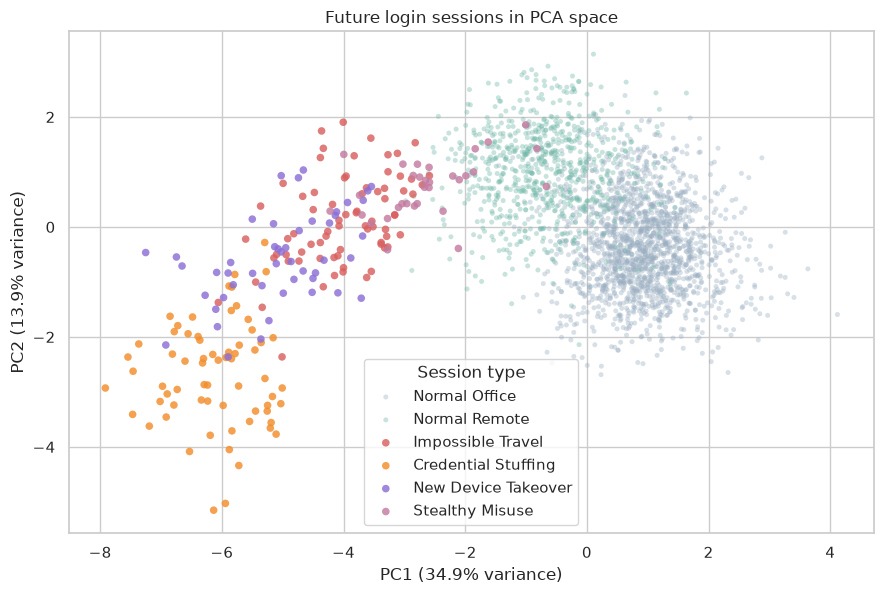

In [4]:
# Section focus: Discussion.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

plot_order = [
    'normal_office',
    'normal_remote',
    'impossible_travel',
    'credential_stuffing',
    'new_device_takeover',
    'stealthy_misuse',
]
fig, ax = plt.subplots(figsize=(9.0, 6.1))
for regime in plot_order:
    subset = future_df[future_df['regime'].eq(regime)]
    is_normal = regime.startswith('normal')
    ax.scatter(
        subset['pc1'], subset['pc2'],
        s=13 if is_normal else 30,
        alpha=0.38 if is_normal else 0.82,
        color=PALETTE[regime],
        label=regime.replace('_', ' ').title(),
        edgecolor='none',
    )
ax.set_title('Future login sessions in PCA space')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend(title='Session type', loc='best', frameon=True)
plt.tight_layout()
plt.show()

The PCA projection gives us an audit view. It shows routine office and remote sessions, plus several risky patterns. Some risk types are visibly separated; others sit closer to normal remote behavior. That is exactly where one-class methods require careful thresholding.

For Feature Engineering for Support Estimation, separate unusual behavior from useful triage. The alert is valuable only when it changes the next review step.


## 6. Fit One-Class SVM Models

We compare three support-vector boundaries:

| Model | Why include it? |
|---|---|
| Linear One-Class SVM | Baseline rigid boundary |
| RBF One-Class SVM with `gamma='scale'` | Practical default nonlinear boundary |
| RBF One-Class SVM with tuned gamma | More explicit bandwidth control |

For evaluation, we compute two operating rules:

1. **Boundary violation:** alert if the model predicts outside the learned support.
2. **Top review budget:** alert the top 5% by anomaly score.

The second rule reflects a fixed review queue. The first reflects the learned model boundary. They can differ substantially.

In [5]:
# Section focus: 6. Fit One-Class SVM Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

REVIEW_BUDGET = 0.05

def fit_ocsvm(kernel='rbf', gamma='scale', nu=0.04):
    """Fit the ocsvm model or object used in the 08. One-Class Classification and Support Vector Methods analysis.
    
    Parameters
    ----------
    kernel : object
        The kernel setting that controls the ocsvm calculation in this notebook.
    gamma : object
        The gamma setting that controls the ocsvm calculation in this notebook.
    nu : object
        The nu setting that controls the ocsvm calculation in this notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    model = OneClassSVM(kernel=kernel, gamma=gamma, nu=nu)
    model.fit(Z_train)
    future_score = -model.decision_function(Z_future).ravel()
    train_score = -model.decision_function(Z_train).ravel()
    boundary_alert = model.predict(Z_future).eq(-1) if hasattr(model.predict(Z_future), 'eq') else (model.predict(Z_future) == -1)
    top_cutoff = np.quantile(future_score, 1 - REVIEW_BUDGET)
    top_alert = future_score >= top_cutoff
    return model, future_score, train_score, boundary_alert, top_alert, top_cutoff

def evaluate_rule(score, alert, label, model, train_score):
    """Evaluate rule for the 08. One-Class Classification and Support Vector Methods decision workflow.
    
    Parameters
    ----------
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    alert : object
        The alert setting that controls the rule calculation in this notebook.
    label : object
        Human-readable label used to name a model, scenario, metric, or plotted series.
    model : object
        Fitted model or model specification used by this step.
    train_score : object
        Training split or training value used by this workflow.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    alert = np.asarray(alert, dtype=bool)
    y = future_df['known_anomaly'].to_numpy().astype(bool)
    false_alert_mask = alert & ~y
    return {
        'rule': label,
        'alerts': int(alert.sum()),
        'alert_rate': alert.mean(),
        'precision': y[alert].mean() if alert.sum() else np.nan,
        'recall': (alert & y).sum() / y.sum(),
        'false_positive_rate': false_alert_mask.sum() / (~y).sum(),
        'false_alerts': int(false_alert_mask.sum()),
        'normal_remote_share_of_false_alerts': future_df.loc[false_alert_mask, 'regime'].eq('normal_remote').mean() if false_alert_mask.sum() else 0,
        'average_precision': average_precision_score(y, score),
        'roc_auc': roc_auc_score(y, score),
        'train_rejection_rate': (train_score > 0).mean(),
        'support_vector_fraction': model.support_.size / len(Z_train),
    }

model_specs = [
    {'name': 'Linear One-Class SVM', 'kernel': 'linear', 'gamma': 'scale', 'nu': 0.04},
    {'name': 'RBF One-Class SVM, gamma=scale', 'kernel': 'rbf', 'gamma': 'scale', 'nu': 0.04},
    {'name': 'RBF One-Class SVM, gamma=0.05', 'kernel': 'rbf', 'gamma': 0.05, 'nu': 0.04},
]

model_store = {}
comparison_rows = []
for spec in model_specs:
    model, score, train_score, boundary_alert, top_alert, top_cutoff = fit_ocsvm(
        kernel=spec['kernel'], gamma=spec['gamma'], nu=spec['nu']
    )
    model_store[spec['name']] = {
        'model': model,
        'score': score,
        'train_score': train_score,
        'boundary_alert': boundary_alert,
        'top_alert': top_alert,
        'top_cutoff': top_cutoff,
        'spec': spec,
    }
    comparison_rows.append(evaluate_rule(score, boundary_alert, f'{spec["name"]}: model boundary', model, train_score))
    comparison_rows.append(evaluate_rule(score, top_alert, f'{spec["name"]}: top 5% review', model, train_score))

comparison_table = pd.DataFrame(comparison_rows)
smart_display(comparison_table.style.format({
    'alert_rate': '{:.1%}',
    'precision': '{:.1%}',
    'recall': '{:.1%}',
    'false_positive_rate': '{:.2%}',
    'normal_remote_share_of_false_alerts': '{:.1%}',
    'average_precision': '{:.1%}',
    'roc_auc': '{:.3f}',
    'train_rejection_rate': '{:.1%}',
    'support_vector_fraction': '{:.1%}',
}))

,rule,alerts,alert_rate,precision,recall,false_positive_rate,false_alerts,normal_remote_share_of_false_alerts,average_precision,roc_auc,train_rejection_rate,support_vector_fraction
0,Linear One-Class SVM: model boundary,1509,56.5%,3.5%,24.1%,59.43%,1456,26.3%,5.2%,0.234,62.0%,4.8%
1,Linear One-Class SVM: top 5% review,134,5.0%,5.2%,3.2%,5.18%,127,46.5%,5.2%,0.234,62.0%,4.8%
2,"RBF One-Class SVM, gamma=scale: model boundary",389,14.6%,56.6%,100.0%,6.90%,169,48.5%,99.4%,0.999,4.4%,6.5%
3,"RBF One-Class SVM, gamma=scale: top 5% review",134,5.0%,100.0%,60.9%,0.00%,0,0.0%,99.4%,0.999,4.4%,6.5%
4,"RBF One-Class SVM, gamma=0.05: model boundary",332,12.4%,66.3%,100.0%,4.57%,112,52.7%,99.6%,1.000,3.9%,4.4%
5,"RBF One-Class SVM, gamma=0.05: top 5% review",134,5.0%,100.0%,60.9%,0.00%,0,0.0%,99.6%,1.000,3.9%,4.4%


The boundary rule and the review-budget rule answer different questions. The model boundary asks, "Is this outside the learned support?" The review-budget rule asks, "Which cases should fill today's review queue?"

In this example, the RBF models produce excellent rankings. But their learned boundary may reject more cases than the team can review. That is a launch-policy issue; it means the launch policy needs an explicit operating threshold.

The linear model is included as a useful failure mode. With centered, multi-regime normal data, a linear one-class boundary can be geometrically awkward because the origin can sit near the normal cloud rather than outside it. The realized training rejection rate exposes that mismatch.

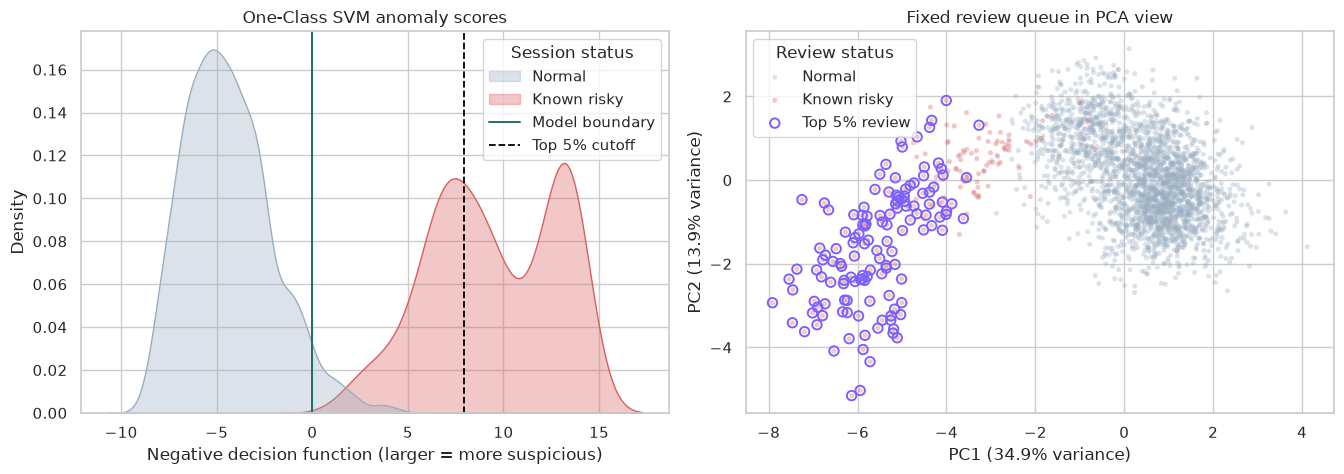

In [6]:
# Section focus: Discussion.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

recommended_name = 'RBF One-Class SVM, gamma=0.05'
recommended = model_store[recommended_name]
future_df['ocsvm_score'] = recommended['score']
future_df['ocsvm_boundary_alert'] = recommended['boundary_alert']
future_df['ocsvm_review_alert'] = recommended['top_alert']
ocsvm_cutoff = recommended['top_cutoff']
ocsvm_model = recommended['model']
train_scores = recommended['train_score']

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.9))

sns.kdeplot(
    data=future_df,
    x='ocsvm_score',
    hue='known_anomaly',
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette={0: PALETTE['normal_office'], 1: PALETTE['impossible_travel']},
    ax=axes[0],
)
axes[0].axvline(0, color=PALETTE['boundary'], linestyle='-', linewidth=1.4, label='Model boundary')
axes[0].axvline(ocsvm_cutoff, color='black', linestyle='--', linewidth=1.3, label='Top 5% cutoff')
axes[0].set_title('One-Class SVM anomaly scores')
axes[0].set_xlabel('Negative decision function (larger = more suspicious)')
axes[0].set_ylabel('Density')
axes[0].legend(
    handles=[
        Patch(facecolor=PALETTE['normal_office'], edgecolor=PALETTE['normal_office'], alpha=0.35, label='Normal'),
        Patch(facecolor=PALETTE['impossible_travel'], edgecolor=PALETTE['impossible_travel'], alpha=0.35, label='Known risky'),
        Line2D([0], [0], color=PALETTE['boundary'], linestyle='-', linewidth=1.4, label='Model boundary'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=1.3, label='Top 5% cutoff'),
    ],
    title='Session status',
    frameon=True,
)

for known, label, color in [(0, 'Normal', PALETTE['normal_office']), (1, 'Known risky', PALETTE['impossible_travel'])]:
    subset = future_df[future_df['known_anomaly'].eq(known)]
    axes[1].scatter(subset['pc1'], subset['pc2'], s=13, alpha=0.35, color=color, label=label, edgecolor='none')
alert_subset = future_df[future_df['ocsvm_review_alert']]
axes[1].scatter(
    alert_subset['pc1'], alert_subset['pc2'],
    s=46, facecolors='none', edgecolors=PALETTE['alert'], linewidths=1.4, label='Top 5% review'
)
axes[1].set_title('Fixed review queue in PCA view')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].legend(title='Review status', frameon=True, loc='best')
plt.tight_layout()
plt.show()

The vertical line at zero is the model's learned boundary. Points to the right of zero have negative decision-function values and are outside the learned support. The dashed line is more restrictive: it fills only the top 5% review queue.

This is a useful operational distinction. The one-class boundary can be used as a monitoring signal, while the review threshold can be tuned to match available analyst capacity.

## 7. Sensitivity to `nu` and `gamma`

One-Class SVM is powerful but sensitive. The `nu` parameter controls boundary tightness. The RBF `gamma` parameter controls how local the support estimate becomes.

We will sweep both and evaluate the fixed 5% review queue. This isolates ranking quality from the size of the model boundary.

,nu,gamma,precision,recall,average_precision,roc_auc,model_boundary_alert_rate,train_rejection_rate,support_vector_fraction,normal_remote_share_of_false_alerts
0,0.02,0.02,100.0%,60.9%,99.5%,0.999,10.1%,2.0%,2.4%,0.0%
1,0.02,0.05,100.0%,60.9%,99.3%,0.999,10.9%,2.1%,2.9%,0.0%
2,0.02,0.10,100.0%,60.9%,99.3%,0.999,12.9%,2.5%,4.6%,0.0%
3,0.02,0.20,100.0%,60.9%,99.4%,0.999,21.4%,6.7%,13.0%,0.0%
4,0.04,0.02,100.0%,60.9%,99.6%,1.000,11.8%,4.0%,4.2%,0.0%
5,0.04,0.05,100.0%,60.9%,99.6%,1.000,12.4%,3.9%,4.4%,0.0%
6,0.04,0.10,100.0%,60.9%,99.4%,0.999,14.0%,4.6%,6.1%,0.0%
7,0.04,0.20,100.0%,60.9%,99.4%,0.999,21.4%,6.5%,13.0%,0.0%
8,0.08,0.02,100.0%,60.9%,99.6%,1.000,15.9%,8.1%,8.2%,0.0%
9,0.08,0.05,100.0%,60.9%,99.4%,0.999,16.5%,8.0%,8.5%,0.0%


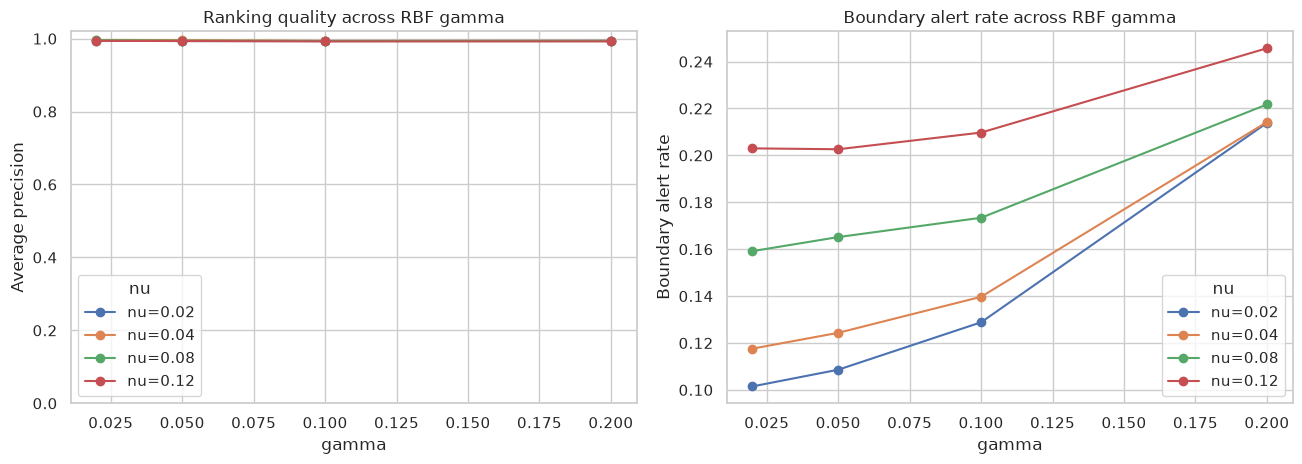

In [7]:
# Section focus: 7. Sensitivity to nu and gamma.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

sensitivity_rows = []
for nu in [0.02, 0.04, 0.08, 0.12]:
    for gamma in [0.02, 0.05, 0.10, 0.20]:
        model, score, train_score, boundary_alert, top_alert, top_cutoff = fit_ocsvm(kernel='rbf', gamma=gamma, nu=nu)
        row = evaluate_rule(score, top_alert, f'nu={nu:.2f}, gamma={gamma:.2f}: top 5%', model, train_score)
        row['nu'] = nu
        row['gamma'] = gamma
        row['model_boundary_alert_rate'] = np.asarray(boundary_alert).mean()
        row['top_cutoff'] = top_cutoff
        sensitivity_rows.append(row)

sensitivity_table = pd.DataFrame(sensitivity_rows)
smart_display(sensitivity_table[[
    'nu', 'gamma', 'precision', 'recall', 'average_precision', 'roc_auc',
    'model_boundary_alert_rate', 'train_rejection_rate', 'support_vector_fraction',
    'normal_remote_share_of_false_alerts'
]].style.format({
    'nu': '{:.2f}',
    'gamma': '{:.2f}',
    'precision': '{:.1%}',
    'recall': '{:.1%}',
    'average_precision': '{:.1%}',
    'roc_auc': '{:.3f}',
    'model_boundary_alert_rate': '{:.1%}',
    'train_rejection_rate': '{:.1%}',
    'support_vector_fraction': '{:.1%}',
    'normal_remote_share_of_false_alerts': '{:.1%}',
}))

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))
for nu, subset in sensitivity_table.groupby('nu'):
    axes[0].plot(subset['gamma'], subset['average_precision'], marker='o', label=f'nu={nu:.2f}')
    axes[1].plot(subset['gamma'], subset['model_boundary_alert_rate'], marker='o', label=f'nu={nu:.2f}')
axes[0].set_title('Ranking quality across RBF gamma')
axes[0].set_xlabel('gamma')
axes[0].set_ylabel('Average precision')
axes[0].set_ylim(0, 1.02)
axes[0].legend(title='nu', frameon=True)
axes[1].set_title('Boundary alert rate across RBF gamma')
axes[1].set_xlabel('gamma')
axes[1].set_ylabel('Boundary alert rate')
axes[1].legend(title='nu', frameon=True)
plt.tight_layout()
plt.show()

A model can have excellent ranking quality while its boundary alert rate is too large for the review team. That is why we track both the top-queue metrics and the model-boundary alert rate.

Notice that the top-5% recall is flat in this synthetic example. That is not a bug. The future anomaly rate is about 8.2%, so a perfectly precise 5% review queue can capture at most about 5 / 8.2 = 60.9% of all risky sessions. The queue is saturated with true risky sessions; increasing recall requires either a larger review budget or a second-stage policy.

In production, `nu` and `gamma` should not be chosen by a single metric alone. They should be chosen by considering normal rejection rate, support-vector fraction, queue quality, stability, and segment-level false alerts.

## 8. Boundary Versus Review Queue by Risk Type

The model boundary can flag a large fraction of future sessions. The fixed review queue focuses on the most suspicious cases. We can compare how each rule covers different risk types.

,regime,sessions,known_anomaly,boundary_alert_rate,review_alert_rate,mean_score
0,credential_stuffing,66,1,100.0%,100.0%,13.250
1,impossible_travel,74,1,100.0%,41.9%,7.902
2,new_device_takeover,48,1,100.0%,75.0%,9.581
3,normal_office,1700,0,3.1%,0.0%,-4.888
4,normal_remote,750,0,7.9%,0.0%,-3.167
5,stealthy_misuse,32,1,100.0%,3.1%,5.073


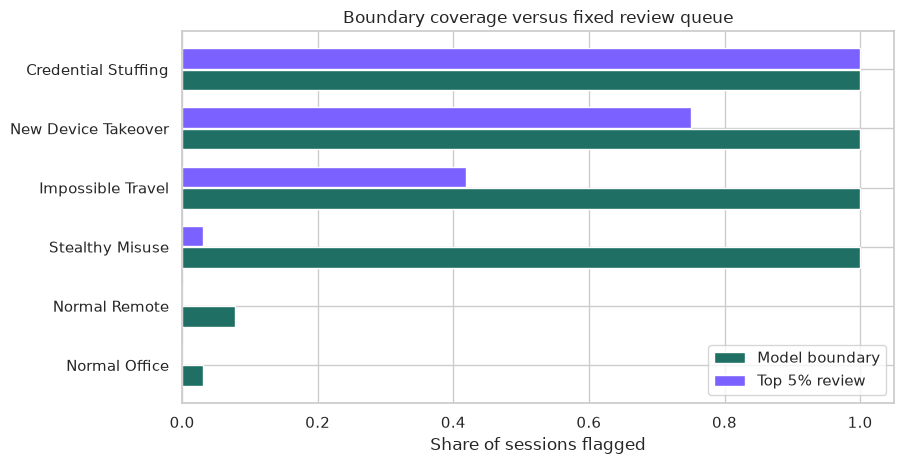

In [8]:
# Section focus: 8. Boundary Versus Review Queue by Risk Type.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

risk_type_table = future_df.groupby('regime').agg(
    sessions=('regime', 'size'),
    known_anomaly=('known_anomaly', 'max'),
    boundary_alert_rate=('ocsvm_boundary_alert', 'mean'),
    review_alert_rate=('ocsvm_review_alert', 'mean'),
    mean_score=('ocsvm_score', 'mean'),
).reset_index()

smart_display(risk_type_table.style.format({
    'boundary_alert_rate': '{:.1%}',
    'review_alert_rate': '{:.1%}',
    'mean_score': '{:.3f}',
}))

fig, ax = plt.subplots(figsize=(9.2, 4.8))
plot_table = risk_type_table.sort_values('mean_score')
y = np.arange(len(plot_table))
ax.barh(y - 0.18, plot_table['boundary_alert_rate'], height=0.35, color=PALETTE['boundary'], label='Model boundary')
ax.barh(y + 0.18, plot_table['review_alert_rate'], height=0.35, color=PALETTE['alert'], label='Top 5% review')
ax.set_yticks(y)
ax.set_yticklabels(plot_table['regime'].str.replace('_', ' ').str.title())
ax.set_xlabel('Share of sessions flagged')
ax.set_title('Boundary coverage versus fixed review queue')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

This table is often more actionable than a single AUC. Security teams need to know which risk types are captured and which normal regimes are being stressed.

If the boundary flags many legitimate remote sessions, the team may use the boundary as a soft signal but reserve review escalation for the highest scores or for cases combined with additional evidence.

## 9. Explaining a Selected Alert

One-Class SVM decisions are kernel-boundary decisions, so explanations are not as direct as a simple rule. We can still provide useful context:

1. nearest normal neighbors from the training baseline,
2. feature gaps between the selected alert and those neighbors, and
3. score-drop diagnostics from replacing one feature at a time with its normal median.

These diagnostics are not causal. They describe why the session looks outside normal support to this model.

,feature,case_value,neighbor_mean,neighbor_standardized_gap
3,Failed Attempts,10.00,1.20,18.17
5,IP Reputation Score,84.35,22.79,7.34
4,Device Risk Score,84.59,30.02,5.77
6,MFA Prompts,6.00,1.17,5.53
7,Session Duration (min),5.59,28.17,-1.84
8,Account Age (days),16.08,372.69,-1.83
0,Login Hour Sine,-1.00,-0.63,-0.97
1,Login Hour Cosine,0.10,0.20,-0.15
2,Geo Velocity (km/h),67.22,63.20,0.09


,feature,mean_score_drop_when_replaced_by_normal_median,median_score_drop_when_replaced_by_normal_median
3,Log Failed Attempts,2.2263,1.8603
8,Log Account Age (days),1.5329,0.6276
2,Log Geo Velocity (km/h),0.7342,0.0473
6,Log MFA Prompts,0.5717,0.3148
7,Log Session Duration (min),0.4869,0.3215
5,Log IP Reputation Score,0.4175,0.2681
4,Log Device Risk Score,0.2977,0.1479
0,Login Hour Sine,0.2063,0.0627
1,Login Hour Cosine,-0.0994,-0.0497


,Quantity,Value
0,Selected future session id,2549
1,Known label,1
2,Regime,credential_stuffing
3,One-Class SVM score,13.904
4,Top 5% cutoff,7.938
5,Inside model boundary?,False
6,Nearest-neighbor normal remote share,80.0%


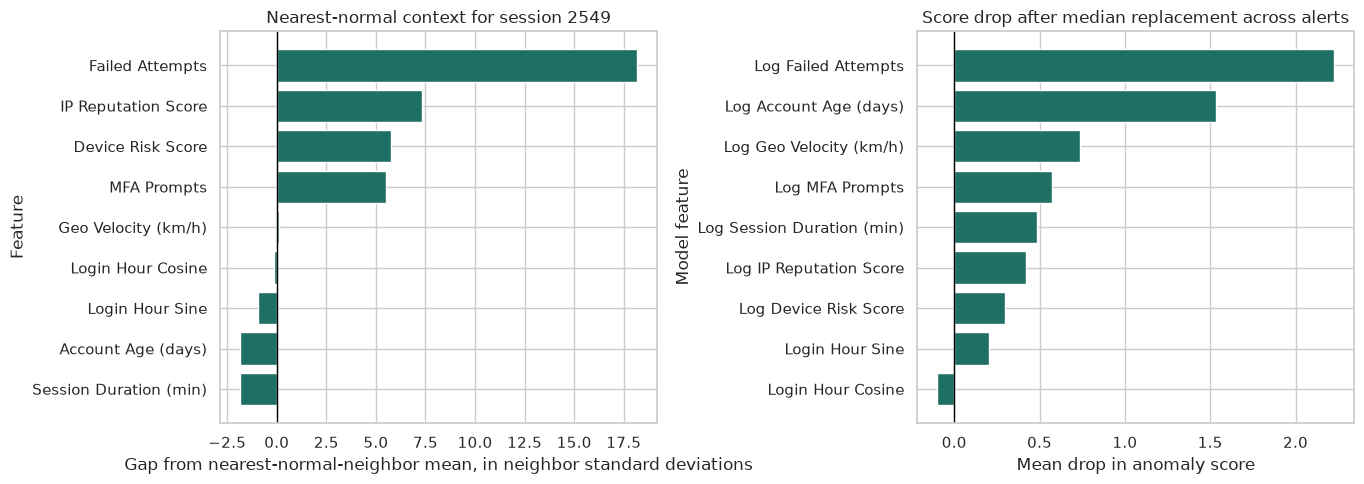

In [9]:
# Section focus: 9. Explaining a Selected Alert.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

alert_pool = future_df[future_df['ocsvm_review_alert']].copy()
true_alert_pool = alert_pool[alert_pool['known_anomaly'].eq(1)]
selected_idx = (true_alert_pool if len(true_alert_pool) else alert_pool).sort_values('ocsvm_score', ascending=False).index[0]
selected = future_df.loc[selected_idx]

nn = NearestNeighbors(n_neighbors=30)
nn.fit(Z_train)
distances, neighbor_positions = nn.kneighbors(Z_future[[selected_idx]])
neighbors_raw = train_df.iloc[neighbor_positions[0]]

neighbor_mean = neighbors_raw[raw_feature_cols].mean()
neighbor_sd = neighbors_raw[raw_feature_cols].std().replace(0, np.nan)
standardized_gap = (selected[raw_feature_cols].astype(float) - neighbor_mean) / neighbor_sd

local_explanation = pd.DataFrame({
    'feature': [PRETTY_FEATURE_NAMES[col] for col in raw_feature_cols],
    'case_value': selected[raw_feature_cols].astype(float).to_numpy(),
    'neighbor_mean': neighbor_mean.to_numpy(dtype=float),
    'neighbor_standardized_gap': standardized_gap.to_numpy(dtype=float),
}).sort_values('neighbor_standardized_gap', key=lambda s: s.abs(), ascending=False)

normal_medians = pd.Series(np.median(Z_train, axis=0), index=X_train.columns)
base_alert_scores = future_df.loc[future_df['ocsvm_review_alert'], 'ocsvm_score'].to_numpy()
alert_positions = np.where(future_df['ocsvm_review_alert'].to_numpy())[0]
score_drop_rows = []
for j, feature in enumerate(X_train.columns):
    modified = Z_future[alert_positions].copy()
    modified[:, j] = normal_medians[feature]
    modified_scores = -ocsvm_model.decision_function(modified).ravel()
    score_drop_rows.append({
        'feature': DISPLAY_NAMES[feature],
        'mean_score_drop_when_replaced_by_normal_median': float(np.mean(base_alert_scores - modified_scores)),
        'median_score_drop_when_replaced_by_normal_median': float(np.median(base_alert_scores - modified_scores)),
    })
score_drop_table = pd.DataFrame(score_drop_rows).sort_values(
    'mean_score_drop_when_replaced_by_normal_median', ascending=False
)

case_summary = pd.DataFrame({
    'Quantity': [
        'Selected future session id',
        'Known label',
        'Regime',
        'One-Class SVM score',
        'Top 5% cutoff',
        'Inside model boundary?',
        'Nearest-neighbor normal remote share',
    ],
    'Value': [
        str(selected_idx),
        str(int(selected['known_anomaly'])),
        str(selected['regime']),
        f'{selected["ocsvm_score"]:.3f}',
        f'{ocsvm_cutoff:.3f}',
        str(bool(selected['ocsvm_score'] < 0)),
        f'{neighbors_raw["regime"].eq("normal_remote").mean():.1%}',
    ],
})

smart_display(local_explanation.style.format({
    'case_value': '{:.2f}',
    'neighbor_mean': '{:.2f}',
    'neighbor_standardized_gap': '{:.2f}',
}))
smart_display(score_drop_table.style.format({
    'mean_score_drop_when_replaced_by_normal_median': '{:.4f}',
    'median_score_drop_when_replaced_by_normal_median': '{:.4f}',
}))
smart_display(case_summary)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.0))
plot_gap = local_explanation.sort_values('neighbor_standardized_gap')
axes[0].barh(plot_gap['feature'], plot_gap['neighbor_standardized_gap'], color=PALETTE['decision'])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title(f'Nearest-normal context for session {selected_idx}')
axes[0].set_xlabel('Gap from nearest-normal-neighbor mean, in neighbor standard deviations')
axes[0].set_ylabel('Feature')

plot_drop = score_drop_table.sort_values('mean_score_drop_when_replaced_by_normal_median')
axes[1].barh(plot_drop['feature'], plot_drop['mean_score_drop_when_replaced_by_normal_median'], color=PALETTE['boundary'])
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Score drop after median replacement across alerts')
axes[1].set_xlabel('Mean drop in anomaly score')
axes[1].set_ylabel('Model feature')
plt.tight_layout()
plt.show()

The selected alert explanation combines raw operational values with model-space diagnostics. The nearest-neighbor table tells the analyst what is unusual relative to normal training sessions. The score-drop plot shows which transformed features most reduce the model score when moved toward normal medians.

Large standardized gaps can occur when local normal neighbors have very little variation on a feature. The raw value and neighbor mean should always be inspected alongside the standardized gap.

## 10. Decision Memo

The final step is to convert the one-class analysis into a launch recommendation. The memo should separate model-boundary monitoring from review-queue escalation.

In [10]:
# Section focus: 10. Decision Memo.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

recommended_boundary = comparison_table[comparison_table['rule'].eq(f'{recommended_name}: model boundary')].iloc[0]
recommended_top = comparison_table[comparison_table['rule'].eq(f'{recommended_name}: top 5% review')].iloc[0]

memo = pd.DataFrame({
    'Memo item': [
        'Recommended launch score',
        'Operating threshold',
        'Expected review quality',
        'Boundary monitoring',
        'Why not linear?',
        'Main false-alert risk',
        'Monitoring plan',
        'Human-review instruction',
    ],
    'Decision note': [
        f'Use the RBF One-Class SVM score with nu = 0.04 and gamma = 0.05 as the first-pass ranked score.',
        f'Escalate the top {REVIEW_BUDGET:.0%} of future sessions by score; current cutoff is {ocsvm_cutoff:.3f}.',
        f'The top-review rule has precision {recommended_top["precision"]:.1%} and recall {recommended_top["recall"]:.1%} in this synthetic evaluation; recall is capped by the 5% queue size because risky sessions are more common than the review budget.',
        f'The model boundary flags {recommended_boundary["alert_rate"]:.1%} of future sessions with recall {recommended_boundary["recall"]:.1%}; use it as a soft monitoring signal unless review capacity expands.',
        'The linear boundary performs poorly because normal login behavior has multiple regimes and nonlinear structure.',
        'Legitimate remote sessions may sit near the boundary; monitor false alerts by remote-work segment and device history.',
        'Track support-vector fraction, normal rejection rate, boundary alert rate, review precision, risk-type coverage, and score drift.',
        'Show nearest-normal-neighbor context and feature score-drop diagnostics for each escalated session.',
    ],
})

smart_display(memo)

,Memo item,Decision note
0,Recommended launch score,Use the RBF One-Class SVM score with nu = 0.04 and gamma = 0.05 as the first-pass ranked score.
1,Operating threshold,Escalate the top 5% of future sessions by score; current cutoff is 7.938.
2,Expected review quality,The top-review rule has precision 100.0% and recall 60.9% in this synthetic evaluation; recall is capped by the 5% queue size because risky sessions are more common than the review budget.
3,Boundary monitoring,The model boundary flags 12.4% of future sessions with recall 100.0%; use it as a soft monitoring signal unless review capacity expands.
4,Why not linear?,The linear boundary performs poorly because normal login behavior has multiple regimes and nonlinear structure.
5,Main false-alert risk,Legitimate remote sessions may sit near the boundary; monitor false alerts by remote-work segment and device history.
6,Monitoring plan,"Track support-vector fraction, normal rejection rate, boundary alert rate, review precision, risk-type coverage, and score drift."
7,Human-review instruction,Show nearest-normal-neighbor context and feature score-drop diagnostics for each escalated session.


Decision Memo is less about the score itself and more about whether the score creates an actionable investigation path.


## Key Takeaways

- One-class classification estimates the support of normal behavior from target-class examples.
- SVDD fits a compact data description; One-Class SVM separates normal data from the origin in a kernel feature space.
- The `nu` parameter controls tolerated training rejection and support-vector behavior.
- RBF `gamma` controls boundary locality and can strongly affect boundary alert rates.
- The model boundary and the operational review threshold are different decisions.
- One-Class SVM requires careful feature engineering and scaling.
- Boundary violations should be monitored by segment so legitimate remote work, new devices, or changing behavior are not systematically over-alerted.
- Explanations should combine nearest-normal context, raw feature values, and score diagnostics.

## References

Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys, 41*(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)

Goernitz, N., Kloft, M., Rieck, K., & Brefeld, U. (2013). Toward supervised anomaly detection. *Journal of Artificial Intelligence Research, 46*, 235-262. [https://doi.org/10.1613/jair.3623](https://doi.org/10.1613/jair.3623)

Schölkopf, B., Platt, J. C., Shawe-Taylor, J., Smola, A. J., & Williamson, R. C. (2001). Estimating the support of a high-dimensional distribution. *Neural Computation, 13*(7), 1443-1471. [https://doi.org/10.1162/089976601750264965](https://doi.org/10.1162/089976601750264965)

Tax, D. M. J., & Duin, R. P. W. (2004). Support Vector Data Description. *Machine Learning, 54*(1), 45-66. [https://doi.org/10.1023/B:MACH.0000008084.60811.49](https://doi.org/10.1023/B:MACH.0000008084.60811.49)

Thomas, A., Feuillard, V., & Gramfort, A. (2015). Calibration of One-Class SVM for MV set estimation. *2015 IEEE International Conference on Data Science and Advanced Analytics*, 1-9. [https://doi.org/10.1109/DSAA.2015.7344789](https://doi.org/10.1109/DSAA.2015.7344789)
